##### Classical SVM Implementation - Spambase - SelectKBest

In [1]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (classification_report, accuracy_score, 
                             confusion_matrix, precision_score, 
                             recall_score, f1_score, balanced_accuracy_score)
from sklearn.feature_selection import VarianceThreshold

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load data first
lung_cancer_column_names = ['label'] + [f'attr_{i}' for i in range(1, 57)]
file_path_lung = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\lung+cancer\lung-cancer.data'

# reads the data, treating "?" as missing values
df_lung = pd.read_csv(file_path_lung, header=None, names=lung_cancer_column_names, na_values=['?'])

print(f"Original shape of Lung Cancer data: {df_lung.shape}")

Original shape of Lung Cancer data: (32, 57)


In [ ]:
# ==========================================
# PREPROCESSING 
# ==========================================

print("\n" + "="*80)
print("LUNG CANCER DATASET - CLASSICAL SVM EXPERIMENTS")
print("="*80)
print(f"Original shape of Lung Cancer data: {df_lung.shape}")

# --- Handling Missing Values ---
print("\n--- Handling Missing Values ---")
print(f"Total missing values before imputation: {df_lung.isnull().sum().sum()}")

for col in df_lung.columns:
    if df_lung[col].isnull().any():
        mode_val = df_lung[col].mode()[0]
        df_lung[col].fillna(mode_val, inplace=True)
        print(f"  Imputed column '{col}' with mode: {mode_val}")

print(f"Missing values after imputation: {df_lung.isnull().sum().sum()}")


LUNG CANCER DATASET - CLASSICAL SVM EXPERIMENTS
Original shape of Lung Cancer data: (32, 57)

--- Handling Missing Values ---
Total missing values before imputation: 5
  Imputed column 'attr_4' with mode: 1.0
  Imputed column 'attr_38' with mode: 2.0
Missing values after imputation: 0


##### Target Binarization

In [5]:
# Binary label encoding
df_lung['label_binary'] = df_lung['label'].apply(lambda x: 0 if x == 1 else 1)

print(f"\nLabel distribution:")
print(df_lung['label_binary'].value_counts())


Label distribution:
label_binary
1    23
0     9
Name: count, dtype: int64


##### Main Experiment Loop

In [ ]:
# ================================================================================
# EXPERIMENT CONFIGURATION - LUNG CANCER (NO SAMPLE SIZE VARIATION)
# ================================================================================

experiments = []
n_features_list = [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
kernels = ['linear', 'rbf']

exp_id = 1
for k_feat in n_features_list:
    for kernel in kernels:
        experiments.append({
            'id': f'Exp{exp_id:02d}_k{k_feat}_{kernel}',
            'n_features': k_feat,
            'kernel': kernel
        })
        exp_id += 1

print(f"Total experiments configured: {len(experiments)}")
print(f"Parameter Grid:")
print(f"  - Number of Features (k): {n_features_list}")
print(f"  - Kernels: {kernels}")
print(f"  - Total Combinations: {len(n_features_list)} × {len(kernels)} = {len(experiments)}")
print(f"\nPreview of first 5 experiments:")
for exp in experiments[:5]:
    print(f"  {exp['id']}: n_features={exp['n_features']}, kernel={exp['kernel']}")

Total experiments configured: 26
Parameter Grid:
  - Number of Features (k): [2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
  - Kernels: ['linear', 'rbf']
  - Total Combinations: 13 × 2 = 26

Preview of first 5 experiments:
  Exp01_k2_linear: n_features=2, kernel=linear
  Exp02_k2_rbf: n_features=2, kernel=rbf
  Exp03_k3_linear: n_features=3, kernel=linear
  Exp04_k3_rbf: n_features=3, kernel=rbf
  Exp05_k4_linear: n_features=4, kernel=linear


In [ ]:
# ==========================================
# MAIN EXPERIMENT LOOP
# ==========================================

all_results = []

# Separate Features & Target
X_lung = df_lung.drop(['label', 'label_binary'], axis=1)
y_lung_binary = df_lung['label_binary']

for exp_num, config in enumerate(experiments, 1):
    print("\n" + "="*80)
    print(f"EXPERIMENT {exp_num}/{len(experiments)}: {config['id']}")
    print("="*80)
    print(f"  Number of Features: {config['n_features']}")
    print("="*80)

    # ===================================================================
    # 1. TRAIN-TEST SPLIT
    # ===================================================================
    
    X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
        X_lung, y_lung_binary, test_size=0.3, random_state=42, stratify=y_lung_binary
    )

    print(f"\nDataset created: {X_train_lc.shape[0]} train, {X_test_lc.shape[0]} test")

    # ===================================================================
    # 2. ONE-HOT ENCODING
    # ===================================================================
    
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_lc_encoded = pd.DataFrame(
        encoder.fit_transform(X_train_lc),
        columns=encoder.get_feature_names_out()
    )
    X_test_lc_encoded = pd.DataFrame(
        encoder.transform(X_test_lc),
        columns=encoder.get_feature_names_out()
    )

    print("Data encoded successfully")  # FIXED: was "scaled"

    # ===================================================================
    # 3. FEATURE SELECTION - CRAMÉR'S V
    # ===================================================================
    print("\n--- Feature Selection ---")
    
    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        if min((kcorr-1), (rcorr-1)) == 0: 
            return 0
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    
    # Calculate scores on the ENCODED training data
    cramers_scores = {col: cramers_v(X_train_lc_encoded[col], y_train_lc) 
                      for col in X_train_lc_encoded.columns}
    cramers_series = pd.Series(cramers_scores).sort_values(ascending=False)
    
    # Select top n features based on experiment config
    N_FEATURES_TO_SELECT = config['n_features']
    top_features = cramers_series.head(N_FEATURES_TO_SELECT).index.tolist()
    print(f"Top {N_FEATURES_TO_SELECT} features selected:")
    print(top_features)
    
    # Create the final datasets with only the selected features
    X_train_final = X_train_lc_encoded[top_features].values
    X_test_final = X_test_lc_encoded[top_features].values
    
    print(f"\nFinal training data shape: {X_train_final.shape}")
    print(f"Final testing data shape: {X_test_final.shape}\n")
    
    # Store for results
    selected_features = top_features
    n_features_selected = len(selected_features)

    # ===================================================================
    # 4. GRID SEARCH FOR OPTIMAL HYPERPARAMETERS
    # ===================================================================

    kernel_type = config['kernel']
    print(f"\nGrid searching for optimal hyperparameters (Kernel: {kernel_type.upper()})...")
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Build parameter grid based on kernel type
    if kernel_type == 'rbf':
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
            'class_weight': ['balanced', None]
        }
        svm_model = SVC(kernel='rbf', random_state=42)
    else:  # linear
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'class_weight': ['balanced', None]
        }
        svm_model = SVC(kernel='linear', random_state=42)

    grid_search = GridSearchCV(
        svm_model,
        param_grid,
        cv=cv,
        scoring='balanced_accuracy',
        verbose=0,
        n_jobs=-1
    )

    start_train = time.time()
    grid_search.fit(X_train_final, y_train_lc)
    train_time = time.time() - start_train

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_c = best_params['C']
    best_gamma = best_params.get('gamma', None)  
    best_class_weight = best_params['class_weight'] 
    cv_score = grid_search.best_score_

    print(f"  → Best C: {best_c}")
    if best_gamma is not None:
        print(f"  → Best Gamma: {best_gamma}")
    print(f"  → Best Class Weight: {best_class_weight}")  
    print(f"  → CV Score: {cv_score:.4f}")
    print(f"  → Training time: {train_time:.2f}s")
    
    # ===================================================================
    # 5. EVALUATION
    # ===================================================================
    
    y_train_pred = best_model.predict(X_train_final)
    y_test_pred = best_model.predict(X_test_final)

    train_acc = accuracy_score(y_train_lc, y_train_pred)
    test_acc = accuracy_score(y_test_lc, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test_lc, y_test_pred)
    precision = precision_score(y_test_lc, y_test_pred, zero_division=0)
    recall = recall_score(y_test_lc, y_test_pred, zero_division=0)
    f1 = f1_score(y_test_lc, y_test_pred, zero_division=0)
    gen_gap = abs(train_acc - test_acc)

    print(f"\n --- Model Performance ---")
    print(f"  → Train Accuracy: {train_acc:.4f}")
    print(f"  → Test Accuracy: {test_acc:.4f}")
    print(f"  → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  → Precision: {precision:.4f}")
    print(f"  → Recall: {recall:.4f}")
    print(f"  → F1-Score: {f1:.4f}")
    print(f"  → Generalization Gap: {gen_gap:.4f}")
    
    # Print detailed classification report
    print("\n --- Classification Report ---")
    print(classification_report(y_test_lc, y_test_pred, 
                                target_names=['Non-Cancer', 'Cancer'], 
                                zero_division=0))

    # ===================================================================
    # 6. STORE RESULTS
    # ===================================================================
    
    all_results.append({
        'experiment_id': config['id'],
        'exp_number': exp_num,
        'n_features': N_FEATURES_TO_SELECT, 
        'n_features_selected': n_features_selected,  
        'kernel': kernel_type,
        'selected_features': selected_features,
        'best_c': best_c,
        'best_gamma': best_gamma,
        'best_class_weight': best_class_weight,  
        'cv_score': cv_score,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_balanced_acc': test_balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'gen_gap': gen_gap,
        'train_time': train_time,
        'y_test': y_test_lc.tolist(),
        'y_pred': y_test_pred.tolist()
    })

print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETE!")
print("="*80)



EXPERIMENT 1/26: Exp01_k2_linear
  Number of Features: 2

Dataset created: 22 train, 10 test
Data encoded successfully

--- Feature Selection ---
Top 2 features selected:
['attr_13_3', 'attr_26_2']

Final training data shape: (22, 2)
Final testing data shape: (10, 2)


Grid searching for optimal hyperparameters (Kernel: LINEAR)...
  → Best C: 0.01
  → Best Class Weight: balanced
  → CV Score: 0.6333
  → Training time: 6.29s

 --- Model Performance ---
  → Train Accuracy: 0.7273
  → Test Accuracy: 0.8000
  → Test Balanced Accuracy: 0.7619
  → Precision: 0.8571
  → Recall: 0.8571
  → F1-Score: 0.8571
  → Generalization Gap: 0.0727

 --- Classification Report ---
              precision    recall  f1-score   support

  Non-Cancer       0.67      0.67      0.67         3
      Cancer       0.86      0.86      0.86         7

    accuracy                           0.80        10
   macro avg       0.76      0.76      0.76        10
weighted avg       0.80      0.80      0.80        10


EX

##### Results Analysis and Visualization

In [8]:
# ===================================================================
# SAVE RESULTS
# ===================================================================

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
print("\nExperiment Results Summary:")
print(results_df[['experiment_id', 'n_features', 'n_features_selected', 'kernel',
                  'test_acc', 'recall', 'gen_gap']].to_string(index=False))

# Save results
results_df.to_csv('classical_svm_lungcancer_results.csv', index=False)
print("\nResults saved to: classical_svm_lungcancer_results.csv")


Experiment Results Summary:
   experiment_id  n_features  n_features_selected kernel  test_acc   recall  gen_gap
 Exp01_k2_linear           2                    2 linear       0.8 0.857143 0.072727
    Exp02_k2_rbf           2                    2    rbf       0.8 0.857143 0.072727
 Exp03_k3_linear           3                    3 linear       0.6 0.571429 0.127273
    Exp04_k3_rbf           3                    3    rbf       0.8 0.857143 0.072727
 Exp05_k4_linear           4                    4 linear       0.6 0.571429 0.127273
    Exp06_k4_rbf           4                    4    rbf       0.8 0.857143 0.072727
 Exp07_k5_linear           5                    5 linear       0.6 0.428571 0.009091
    Exp08_k5_rbf           5                    5    rbf       0.8 0.857143 0.072727
 Exp09_k6_linear           6                    6 linear       0.6 0.428571 0.009091
    Exp10_k6_rbf           6                    6    rbf       0.8 0.857143 0.072727
 Exp11_k7_linear           7        

In [9]:
# ================================================================================
# BEST CONFIGURATIONS
# ================================================================================

# Separate data by kernel
rbf_data = results_df[results_df['kernel'] == 'rbf'].copy()
linear_data = results_df[results_df['kernel'] == 'linear'].copy()

# Find best configurations
best_rbf_idx = rbf_data['test_acc'].idxmax()
best_rbf = rbf_data.loc[best_rbf_idx]

best_linear_idx = linear_data['test_acc'].idxmax()
best_linear = linear_data.loc[best_linear_idx]

print("\n" + "="*80)
print("BEST CONFIGURATIONS")
print("="*80)

# ==============================================================================
# RBF KERNEL
# ==============================================================================
print("\n" + "─"*80)
print("RBF KERNEL")
print("─"*80)

print(f"\nExperiment ID: {best_rbf['experiment_id']}")
print(f"  → Test Accuracy: {best_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_rbf['precision']:.4f}")
print(f"  → Recall: {best_rbf['recall']:.4f}")
print(f"  → F1-Score: {best_rbf['f1_score']:.4f}")
print(f"  → Generalization Gap: {best_rbf['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Number of Features (k): {int(best_rbf['n_features'])}")
print(f"  → Best C: {best_rbf['best_c']}")
print(f"  → Best Gamma: {best_rbf['best_gamma']}")
print(f"\nSelected Features:")
for i, feat in enumerate(best_rbf['selected_features'], 1):
    print(f"  {i}. {feat}")

# ==============================================================================
# LINEAR KERNEL
# ==============================================================================
print("\n" + "─"*80)
print("LINEAR KERNEL")
print("─"*80)

print(f"\nExperiment ID: {best_linear['experiment_id']}")
print(f"  → Test Accuracy: {best_linear['test_acc']:.4f}")
print(f"  → Precision: {best_linear['precision']:.4f}")
print(f"  → Recall: {best_linear['recall']:.4f}")
print(f"  → F1-Score: {best_linear['f1_score']:.4f}")
print(f"  → Generalization Gap: {best_linear['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Number of Features (k): {int(best_linear['n_features'])}")
print(f"  → Best C: {best_linear['best_c']}")
print(f"\nSelected Features:")
for i, feat in enumerate(best_linear['selected_features'], 1):
    print(f"  {i}. {feat}")

# ==============================================================================
# COMPARISON
# ==============================================================================
print("\n" + "="*80)
print("KERNEL COMPARISON")
print("="*80)

comparison_data = {
    'Metric': ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'Gen Gap', 'Features (k)'],
    'RBF': [
        f"{best_rbf['test_acc']:.4f}",
        f"{best_rbf['precision']:.4f}",
        f"{best_rbf['recall']:.4f}",
        f"{best_rbf['f1_score']:.4f}",
        f"{best_rbf['gen_gap']:.4f}",
        f"{int(best_rbf['n_features'])}"
    ],
    'Linear': [
        f"{best_linear['test_acc']:.4f}",
        f"{best_linear['precision']:.4f}",
        f"{best_linear['recall']:.4f}",
        f"{best_linear['f1_score']:.4f}",
        f"{best_linear['gen_gap']:.4f}",
        f"{int(best_linear['n_features'])}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))
print("\n" + "="*80)



BEST CONFIGURATIONS

────────────────────────────────────────────────────────────────────────────────
RBF KERNEL
────────────────────────────────────────────────────────────────────────────────

Experiment ID: Exp02_k2_rbf
  → Test Accuracy: 0.8000
  → Precision: 0.8571
  → Recall: 0.8571
  → F1-Score: 0.8571
  → Generalization Gap: 0.0727

Configuration:
  → Number of Features (k): 2
  → Best C: 0.01
  → Best Gamma: 0.001

Selected Features:
  1. attr_13_3
  2. attr_26_2

────────────────────────────────────────────────────────────────────────────────
LINEAR KERNEL
────────────────────────────────────────────────────────────────────────────────

Experiment ID: Exp01_k2_linear
  → Test Accuracy: 0.8000
  → Precision: 0.8571
  → Recall: 0.8571
  → F1-Score: 0.8571
  → Generalization Gap: 0.0727

Configuration:
  → Number of Features (k): 2
  → Best C: 0.01

Selected Features:
  1. attr_13_3
  2. attr_26_2

KERNEL COMPARISON

       Metric    RBF Linear
Test Accuracy 0.8000 0.8000
    P


Generating confusion matrices...



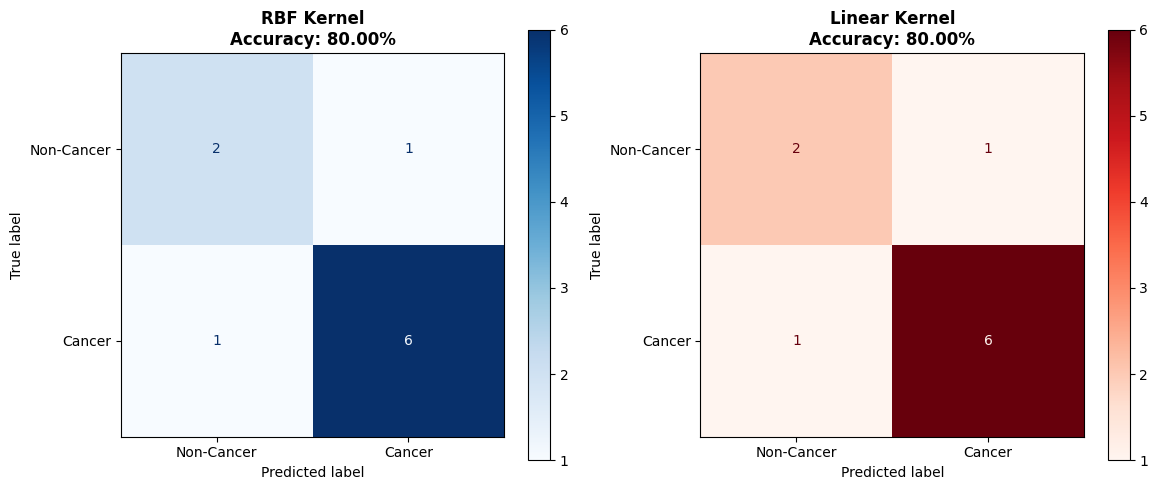

Confusion matrices generated successfully
Saved to: confusion_matrices_lungcancer.png


In [10]:
# ================================================================================
# CONFUSION MATRICES
# ================================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nGenerating confusion matrices...\n")

# Extract stored predictions from best configurations
y_test_rbf = np.array(best_rbf['y_test'])
y_pred_rbf = np.array(best_rbf['y_pred'])

y_test_linear = np.array(best_linear['y_test'])
y_pred_linear = np.array(best_linear['y_pred'])

# Create confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RBF Kernel
cm_rbf = confusion_matrix(y_test_rbf, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, 
                                   display_labels=['Non-Cancer', 'Cancer'])
disp_rbf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'RBF Kernel\nAccuracy: {best_rbf["test_acc"]:.2%}', 
                 fontsize=12, fontweight='bold')

# Linear Kernel
cm_linear = confusion_matrix(y_test_linear, y_pred_linear)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear, 
                                      display_labels=['Non-Cancer', 'Cancer'])
disp_linear.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title(f'Linear Kernel\nAccuracy: {best_linear["test_acc"]:.2%}', 
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_lungcancer.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices generated successfully")
print("Saved to: confusion_matrices_lungcancer.png")



CLASSICAL SVM PERFORMANCE ANALYSIS - LUNG CANCER

--- Plotting: Effect of Feature Count ---


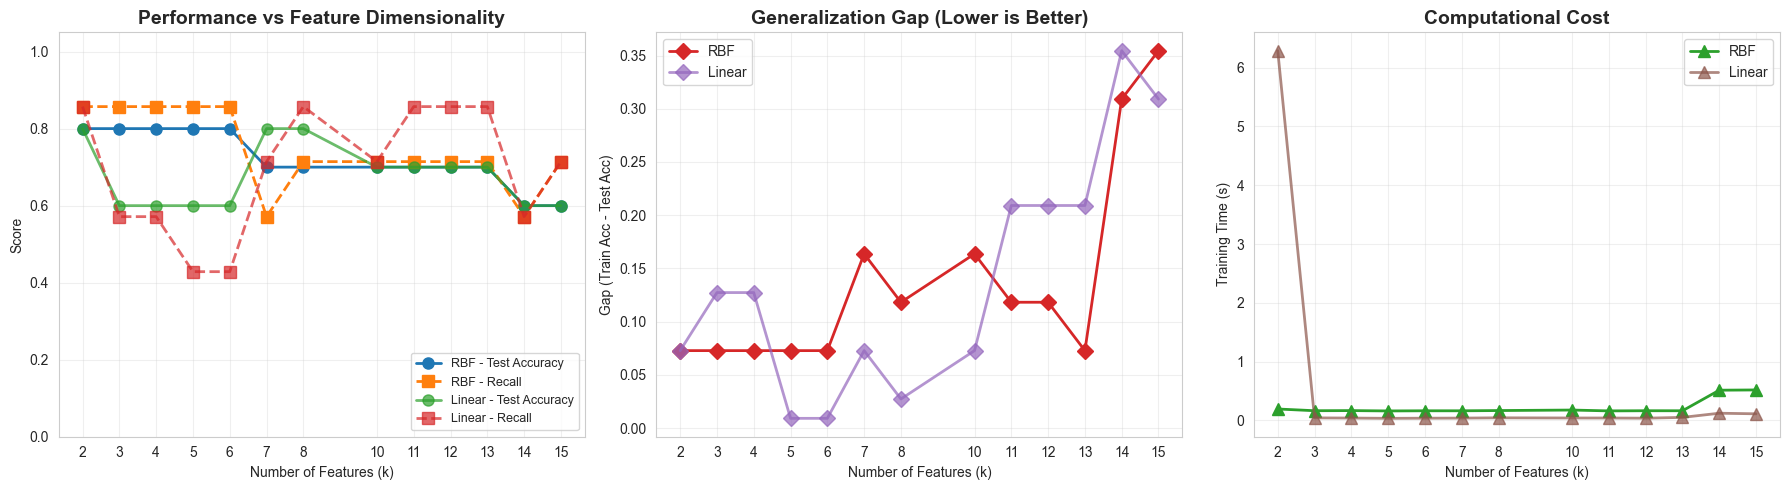


--- Plotting: Accuracy by Feature Count ---


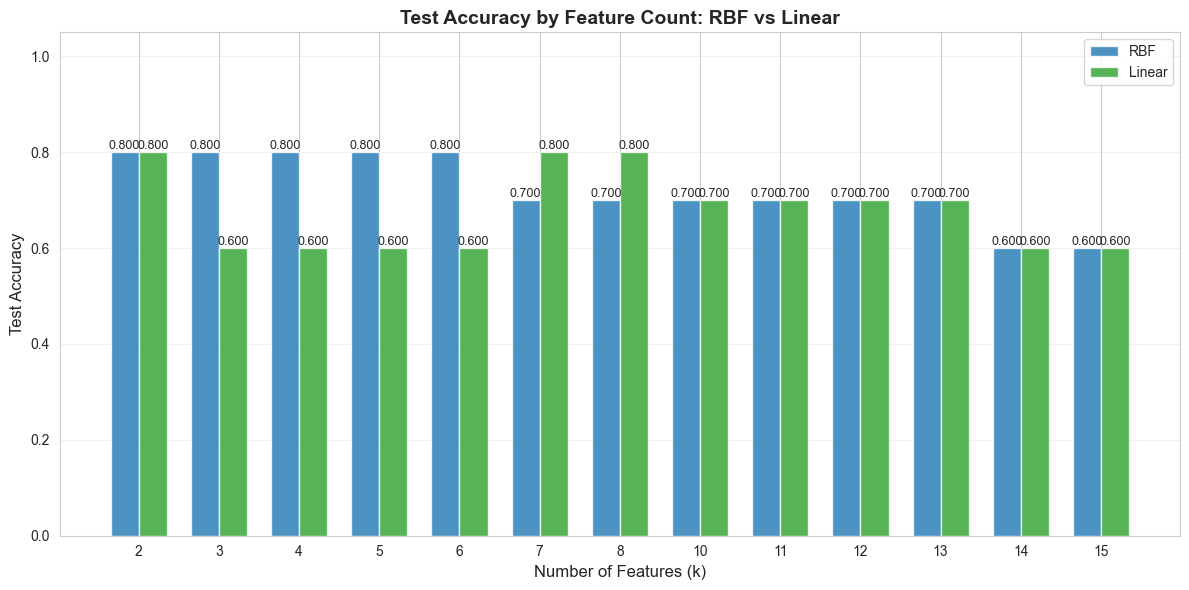


--- Plotting: Best Configs Comparison ---


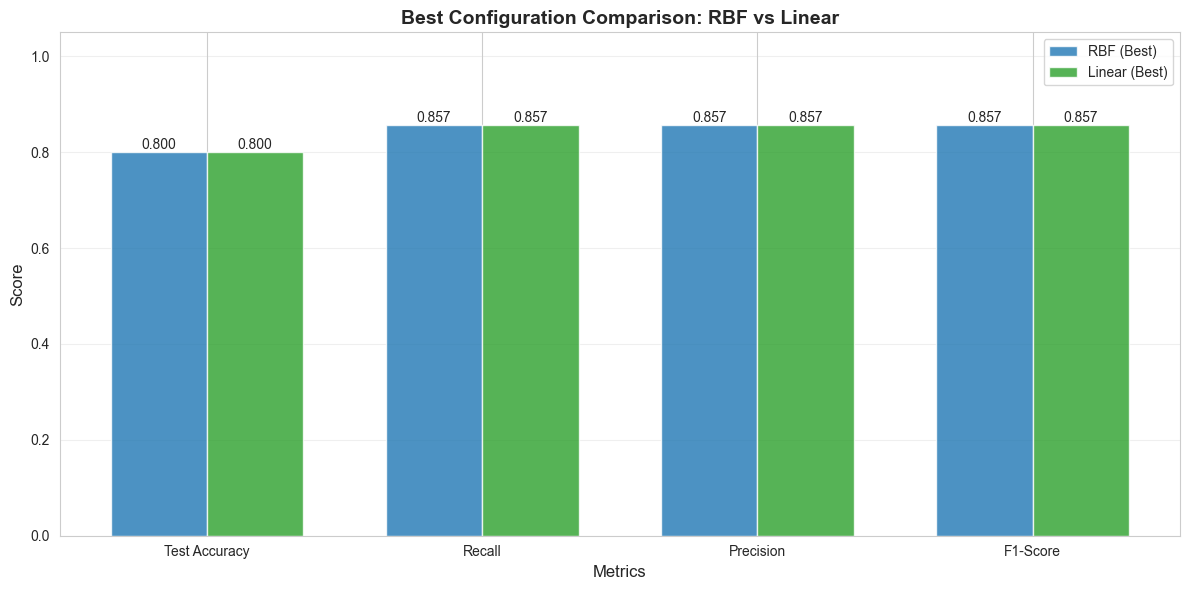


--- Plotting: Comprehensive Metrics Overview ---


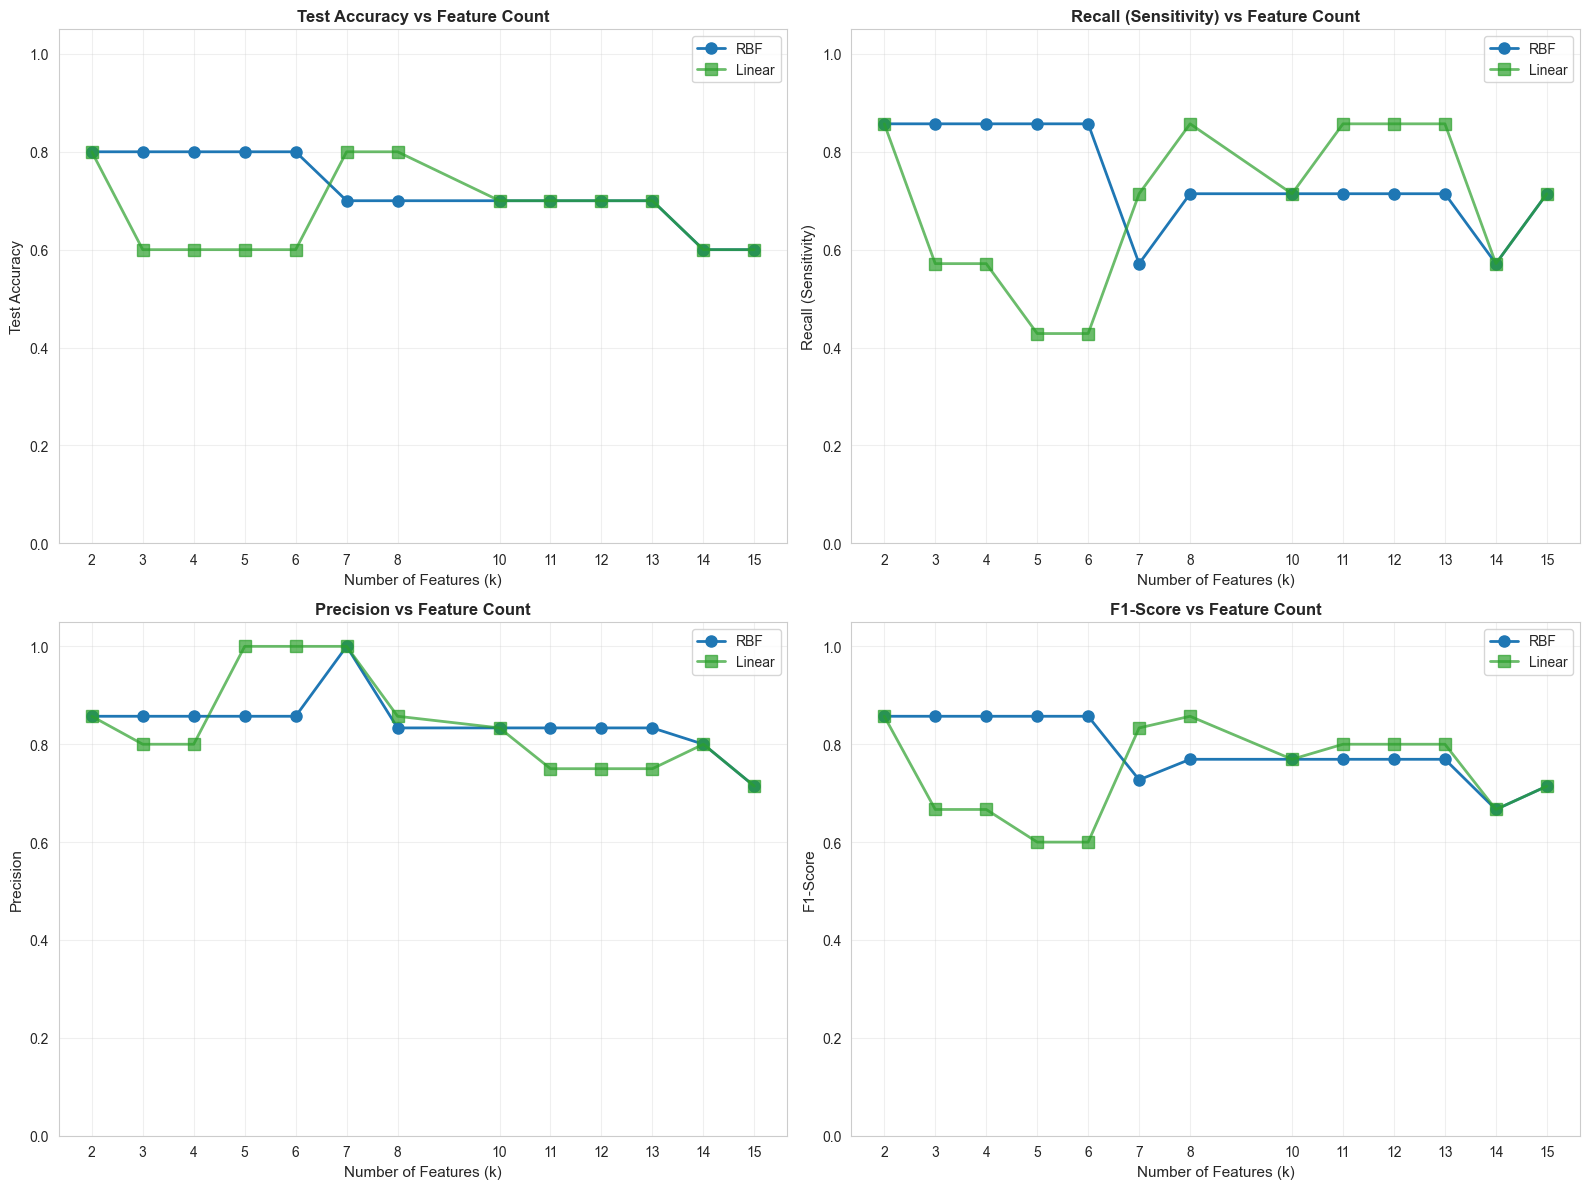


VISUALIZATION COMPLETE!

Saved figures:
  1. lungcancer_feature_effect.png
  2. lungcancer_accuracy_comparison.png
  3. lungcancer_best_config_comparison.png
  4. lungcancer_metrics_overview.png


In [11]:
# ================================================================================
# PERFORMANCE ANALYSIS VISUALIZATIONS
# ================================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURATION & STYLE
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8

def plot_classical_svm_analysis(df):
    """
    Generates standardized visualizations for Classical SVM experiments.
    Compares RBF vs Linear kernels across different feature counts.
    """
    
    print("\n" + "="*80)
    print("CLASSICAL SVM PERFORMANCE ANALYSIS - LUNG CANCER")
    print("="*80)
    
    # Separate by kernel
    rbf_df = df[df['kernel'] == 'rbf'].copy()
    linear_df = df[df['kernel'] == 'linear'].copy()
    
    # ===================================================================
    # PLOT 1: FEATURE DIMENSIONALITY EFFECT
    # ===================================================================
    print("\n--- Plotting: Effect of Feature Count ---")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Group by n_features
    rbf_features = rbf_df.groupby('n_features').agg({
        'test_acc': 'mean',
        'recall': 'mean',
        'gen_gap': 'mean',
        'train_time': 'mean'
    }).reset_index()
    
    linear_features = linear_df.groupby('n_features').agg({
        'test_acc': 'mean',
        'recall': 'mean',
        'gen_gap': 'mean',
        'train_time': 'mean'
    }).reset_index()
    
    # Subplot 1: Performance
    axes[0].plot(rbf_features['n_features'], rbf_features['test_acc'], 'o-', 
                 label='RBF - Test Accuracy', color='#1f77b4', linewidth=2)
    axes[0].plot(rbf_features['n_features'], rbf_features['recall'], 's--', 
                 label='RBF - Recall', color='#ff7f0e', linewidth=2)
    axes[0].plot(linear_features['n_features'], linear_features['test_acc'], 'o-', 
                 label='Linear - Test Accuracy', color='#2ca02c', linewidth=2, alpha=0.7)
    axes[0].plot(linear_features['n_features'], linear_features['recall'], 's--', 
                 label='Linear - Recall', color='#d62728', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Number of Features (k)')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance vs Feature Dimensionality')
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xticks(rbf_features['n_features'])
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Generalization Gap
    axes[1].plot(rbf_features['n_features'], rbf_features['gen_gap'], 'D-', 
                 label='RBF', color='#d62728', linewidth=2)
    axes[1].plot(linear_features['n_features'], linear_features['gen_gap'], 'D-', 
                 label='Linear', color='#9467bd', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Number of Features (k)')
    axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
    axes[1].set_title('Generalization Gap (Lower is Better)')
    axes[1].set_xticks(rbf_features['n_features'])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Training Time
    axes[2].plot(rbf_features['n_features'], rbf_features['train_time'], '^-', 
                 label='RBF', color='#2ca02c', linewidth=2)
    axes[2].plot(linear_features['n_features'], linear_features['train_time'], '^-', 
                 label='Linear', color='#8c564b', linewidth=2, alpha=0.7)
    axes[2].set_xlabel('Number of Features (k)')
    axes[2].set_ylabel('Training Time (s)')
    axes[2].set_title('Computational Cost')
    axes[2].set_xticks(rbf_features['n_features'])
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lungcancer_feature_effect.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===================================================================
    # PLOT 2: PERFORMANCE BAR CHART BY FEATURE COUNT
    # ===================================================================
    print("\n--- Plotting: Accuracy by Feature Count ---")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(rbf_features['n_features']))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, rbf_features['test_acc'], width, 
                   label='RBF', color='#1f77b4', alpha=0.8)
    bars2 = ax.bar(x + width/2, linear_features['test_acc'], width, 
                   label='Linear', color='#2ca02c', alpha=0.8)
    
    ax.set_xlabel('Number of Features (k)', fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.set_title('Test Accuracy by Feature Count: RBF vs Linear', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(rbf_features['n_features'])
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('lungcancer_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===================================================================
    # PLOT 3: METRIC COMPARISON FOR BEST CONFIGURATIONS
    # ===================================================================
    print("\n--- Plotting: Best Configs Comparison ---")
    
    # Get best configs
    best_rbf = rbf_df.loc[rbf_df['test_acc'].idxmax()]
    best_linear = linear_df.loc[linear_df['test_acc'].idxmax()]
    
    metrics = ['test_acc', 'recall', 'precision', 'f1_score']
    metric_labels = ['Test Accuracy', 'Recall', 'Precision', 'F1-Score']
    
    rbf_values = [best_rbf[m] for m in metrics]
    linear_values = [best_linear[m] for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, rbf_values, width, label='RBF (Best)', 
                   color='#1f77b4', alpha=0.8)
    bars2 = ax.bar(x + width/2, linear_values, width, label='Linear (Best)', 
                   color='#2ca02c', alpha=0.8)
    
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Best Configuration Comparison: RBF vs Linear', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('lungcancer_best_config_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===================================================================
    # PLOT 4: ALL METRICS OVERVIEW
    # ===================================================================
    print("\n--- Plotting: Comprehensive Metrics Overview ---")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    metrics_to_plot = [
        ('test_acc', 'Test Accuracy'),
        ('recall', 'Recall (Sensitivity)'),
        ('precision', 'Precision'),
        ('f1_score', 'F1-Score')
    ]
    
    for idx, (metric, label) in enumerate(metrics_to_plot):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]
        
        rbf_metric = rbf_df.groupby('n_features')[metric].mean()
        linear_metric = linear_df.groupby('n_features')[metric].mean()
        
        ax.plot(rbf_metric.index, rbf_metric.values, 'o-', 
                label='RBF', color='#1f77b4', linewidth=2, markersize=8)
        ax.plot(linear_metric.index, linear_metric.values, 's-', 
                label='Linear', color='#2ca02c', linewidth=2, markersize=8, alpha=0.7)
        
        ax.set_xlabel('Number of Features (k)', fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f'{label} vs Feature Count', fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_xticks(rbf_metric.index)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lungcancer_metrics_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*80)
    print("VISUALIZATION COMPLETE!")
    print("="*80)
    print("\nSaved figures:")
    print("  1. lungcancer_feature_effect.png")
    print("  2. lungcancer_accuracy_comparison.png")
    print("  3. lungcancer_best_config_comparison.png")
    print("  4. lungcancer_metrics_overview.png")
    print("="*80)

# ==========================================
# EXECUTION
# ==========================================
plot_classical_svm_analysis(results_df)
